<a href="https://colab.research.google.com/github/willbaker29/willbaker29/blob/main/Projectile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math


In [ ]:
def simulate_projectile(mass):
  diameter = 0.038
  pressure = 370000
  cd = 0.5
  rho = 1.225
  dt = 0.001
  barrel_length = 0.25

  area = math.pi * (diameter / 2)**2

  force = pressure * area

  acceleration = force / mass

  muzzle_velocity = math.sqrt(2 * acceleration * barrel_length)

  return acceleration, muzzle_velocity

In [ ]:
def simulate_trajectory_with_drag(initial_velocity, launch_angle_degrees, mass, diameter=0.038, cd=0.5, rho=1.225, dt=0.001):
    g = 9.81

    launch_angle_rad = math.radians(launch_angle_degrees)

    area = math.pi * (diameter / 2)**2

    # Initial conditions
    x, y = 0.0, 0.0
    vx = initial_velocity * math.cos(launch_angle_rad)
    vy = initial_velocity * math.sin(launch_angle_rad)

    trajectory_points = [(x, y)]
    max_height = 0.0

    while y >= 0 or vy > 0:
        v_total = math.sqrt(vx**2 + vy**2)

        if v_total == 0:
            drag_force_x = 0
            drag_force_y = 0
        else:
            drag_force_magnitude = 0.5 * rho * area * cd * v_total**2

            drag_force_x = -drag_force_magnitude * (vx / v_total)
            drag_force_y = -drag_force_magnitude * (vy / v_total)

        net_fx = drag_force_x
        net_fy = drag_force_y - (mass * g)

        ax = net_fx / mass
        ay = net_fy / mass

        vx += ax * dt
        vy += ay * dt

        x += vx * dt
        y += vy * dt

        if y >= 0:
            trajectory_points.append((x, y))
            if y > max_height:
                max_height = y
        else:
            last_x, last_y = trajectory_points[-1]
            if last_y > 0:
                pass

        if y < 0 and vy < 0:
            break

    final_distance = trajectory_points[-1][0]
    if final_distance < 0:
      final_distance = 0.0

    return final_distance, max_height, trajectory_points

In [ ]:
projectile_mass = 0.01
launch_angle = 5

_, muzzle_vel = simulate_projectile(projectile_mass)
print(f"Muzzle Velocity for mass {projectile_mass} kg: {muzzle_vel:.2f} m/s")

distance, max_height, trajectory = simulate_trajectory_with_drag(muzzle_vel, launch_angle, projectile_mass)

print(f"Launch Angle: {launch_angle} degrees")
print(f"Distance traveled: {distance:.2f} meters")
print(f"Maximum height reached: {max_height:.2f} meters")

Muzzle Velocity for mass 0.01 kg: 144.85 m/s
Launch Angle: 5 degrees
Distance traveled: 57.93 meters
Maximum height reached: 2.30 meters


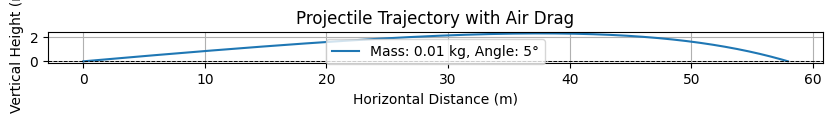

In [ ]:
import matplotlib.pyplot as plt

traj_x = [p[0] for p in trajectory]
traj_y = [p[1] for p in trajectory]

plt.figure(figsize=(10, 6))
plt.plot(traj_x, traj_y, label=f'Mass: {projectile_mass} kg, Angle: {launch_angle}°')
plt.title('Projectile Trajectory with Air Drag')
plt.xlabel('Horizontal Distance (m)')
plt.ylabel('Vertical Height (m)')
plt.grid(True)
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
import numpy as np

masses = np.linspace(0.01, 0.1, 10)
fixed_launch_angle = 5

distances = []
max_heights = []

print(f"Simulating trajectories for masses from {masses.min():.2f} kg to {masses.max():.2f} kg at a fixed launch angle of {fixed_launch_angle}°")

for current_mass in masses:
    _, muzzle_vel = simulate_projectile(current_mass)

    distance, max_h, _ = simulate_trajectory_with_drag(muzzle_vel, fixed_launch_angle, current_mass)

    distances.append(distance)
    max_heights.append(max_h)
    print(f"  Mass: {current_mass:.2f} kg, Muzzle Vel: {muzzle_vel:.2f} m/s, Distance: {distance:.2f} m")

max_distance_index = np.argmax(distances)
optimal_mass = masses[max_distance_index]
max_achieved_distance = distances[max_distance_index]

print(f"\nOptimal mass for maximum distance ({max_achieved_distance:.2f} m) at {fixed_launch_angle}° launch angle: {optimal_mass:.2f} kg")

Simulating trajectories for masses from 0.01 kg to 0.10 kg at a fixed launch angle of 5°
  Mass: 0.01 kg, Muzzle Vel: 144.85 m/s, Distance: 57.93 m
  Mass: 0.02 kg, Muzzle Vel: 102.42 m/s, Distance: 69.36 m
  Mass: 0.03 kg, Muzzle Vel: 83.63 m/s, Distance: 67.87 m
  Mass: 0.04 kg, Muzzle Vel: 72.42 m/s, Distance: 62.36 m
  Mass: 0.05 kg, Muzzle Vel: 64.78 m/s, Distance: 56.16 m
  Mass: 0.06 kg, Muzzle Vel: 59.13 m/s, Distance: 50.36 m
  Mass: 0.07 kg, Muzzle Vel: 54.75 m/s, Distance: 45.32 m
  Mass: 0.08 kg, Muzzle Vel: 51.21 m/s, Distance: 41.01 m
  Mass: 0.09 kg, Muzzle Vel: 48.28 m/s, Distance: 37.33 m
  Mass: 0.10 kg, Muzzle Vel: 45.81 m/s, Distance: 34.20 m

Optimal mass for maximum distance (69.36 m) at 5° launch angle: 0.02 kg


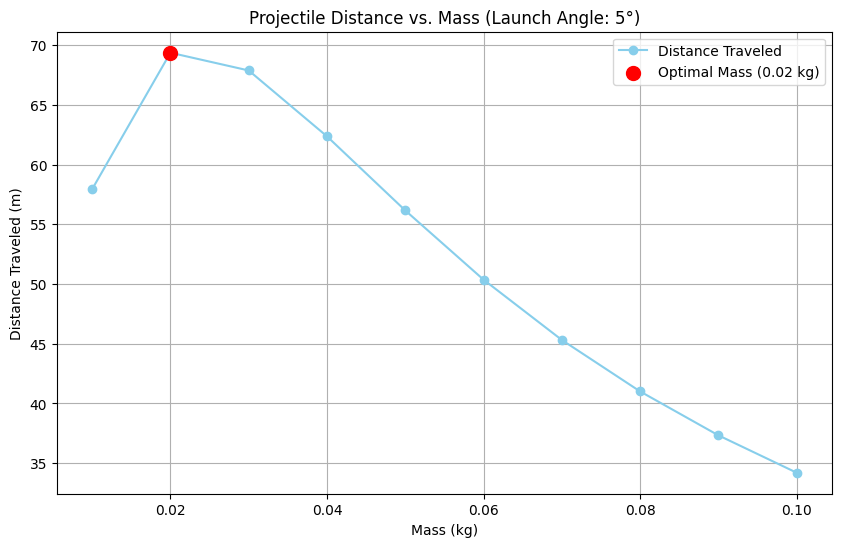

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(masses, distances, marker='o', linestyle='-', color='skyblue', label='Distance Traveled')
plt.scatter(optimal_mass, max_achieved_distance, color='red', s=100, zorder=5, label=f'Optimal Mass ({optimal_mass:.2f} kg)')
plt.title(f'Projectile Distance vs. Mass (Launch Angle: {fixed_launch_angle}°)')
plt.xlabel('Mass (kg)')
plt.ylabel('Distance Traveled (m)')
plt.grid(True)
plt.legend()
plt.show()